In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve,
                           classification_report, confusion_matrix)

from imblearn.combine import SMOTETomek

import tkinter as tk
from tkinter import messagebox, Toplevel
from PIL import Image, ImageTk
import cv2

In [9]:
# Load dataset
df = pd.read_csv('Data.csv')  # Replace with your filename

print("Original dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

# Rename columns (match your exact column names)
df.columns = ['patient_id', 'gender', 'age', 'body_mass_index', 'smoker', 
              'systolic_blood_pressure', 'hypertension_treated', 
              'family_history_cvd', 'atrial_fibrillation', 'chronic_kidney_disease',
              'rheumatoid_arthritis', 'diabetes', 'chronic_obstructive_pulmonary_disorder',
              'forced_expiratory_volume_1', 'time_to_event', 'heart_attack']

# Drop unnecessary columns
df = df.drop(['patient_id', 'time_to_event'], axis=1)

# ============ CONVERT STRING VALUES TO NUMERIC ============

# Handle gender column (M/F or Male/Female)
if df['gender'].dtype == 'object':
    df['gender'] = df['gender'].map({'M': 1, 'F': 0, 'Male': 1, 'Female': 0})

# Handle smoker column (Yes/No or Y/N)
if df['smoker'].dtype == 'object':
    df['smoker'] = df['smoker'].map({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0})

# Handle hypertension_treated
if df['hypertension_treated'].dtype == 'object':
    df['hypertension_treated'] = df['hypertension_treated'].map({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0})

# Handle family_history_cvd
if df['family_history_cvd'].dtype == 'object':
    df['family_history_cvd'] = df['family_history_cvd'].map({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0})

# Handle atrial_fibrillation
if df['atrial_fibrillation'].dtype == 'object':
    df['atrial_fibrillation'] = df['atrial_fibrillation'].map({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0})

# Handle chronic_kidney_disease
if df['chronic_kidney_disease'].dtype == 'object':
    df['chronic_kidney_disease'] = df['chronic_kidney_disease'].map({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0})

# Handle rheumatoid_arthritis
if df['rheumatoid_arthritis'].dtype == 'object':
    df['rheumatoid_arthritis'] = df['rheumatoid_arthritis'].map({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0})

# Handle diabetes
if df['diabetes'].dtype == 'object':
    df['diabetes'] = df['diabetes'].map({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0})

# Handle copd
if df['chronic_obstructive_pulmonary_disorder'].dtype == 'object':
    df['chronic_obstructive_pulmonary_disorder'] = df['chronic_obstructive_pulmonary_disorder'].map({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0})

# ============ HANDLE MISSING VALUES ============
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].median(), inplace=True)

# ============ CREATE ENGINEERED FEATURES ============
df['age_squared'] = df['age'] ** 2
df['bmi_squared'] = df['body_mass_index'] ** 2
df['bp_age_interaction'] = df['systolic_blood_pressure'] * df['age'] / 100
df['risk_score'] = (
    df['smoker'] + df['hypertension_treated'] + df['diabetes'] + 
    df['family_history_cvd'] + df['atrial_fibrillation'] + 
    df['chronic_kidney_disease'] + df['rheumatoid_arthritis'] +
    df['chronic_obstructive_pulmonary_disorder']
)

# ============ DEFINE FEATURES ============
feature_columns = ['gender', 'age', 'body_mass_index', 'smoker', 
                   'systolic_blood_pressure', 'hypertension_treated', 
                   'family_history_cvd', 'atrial_fibrillation', 
                   'chronic_kidney_disease', 'rheumatoid_arthritis', 
                   'diabetes', 'chronic_obstructive_pulmonary_disorder',
                   'forced_expiratory_volume_1', 'age_squared', 'bmi_squared',
                   'bp_age_interaction', 'risk_score']

X = df[feature_columns]
Y = df['heart_attack']

print(f"\n✅ Data preprocessing completed!")
print(f"Features: {len(feature_columns)}")
print(f"Features list: {feature_columns}")
print(f"\nClass distribution:")
print(Y.value_counts())
print(f"Positive class (Heart Attack): {Y.mean()*100:.2f}%")
print(f"\nData types after conversion:")
print(X.dtypes.value_counts())

Original dataset shape: (100000, 16)

First 5 rows:
   patient_id gender  age  body_mass_index  smoker  systolic_blood_pressure  \
0  PT00085957      F   54             25.0       0                    161.0   
1  PT00093111      M   31              NaN       0                    121.0   
2  PT00058456      M   50             31.3       0                    130.0   
3  PT00016352      M   61             30.0       0                    165.0   
4  PT00060611      F   67             32.6       0                    166.0   

   hypertension_treated  family_history_of_cardiovascular_disease  \
0                     0                                         1   
1                     0                                         0   
2                     0                                         0   
3                     0                                         0   
4                     0                                         0   

   atrial_fibrillation  chronic_kidney_disease  rheumatoid

In [10]:
# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42, stratify=Y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train - Heart Attack: {(Y_train == 1).sum()}, No: {(Y_train == 0).sum()}")
print(f"Test - Heart Attack: {(Y_test == 1).sum()}, No: {(Y_test == 0).sum()}")


Training set: 75000 samples
Test set: 25000 samples
Train - Heart Attack: 4959, No: 70041
Test - Heart Attack: 1653, No: 23347


In [11]:
# Convert to float to avoid any issues
X_train = X_train.astype(float)
Y_train = Y_train.astype(float)

# SMOTETomek for balanced dataset
smote_tomek = SMOTETomek(random_state=42)
X_train_balanced, Y_train_balanced = smote_tomek.fit_resample(X_train, Y_train)

print(f"\nAfter SMOTETomek:")
print(f"Training set: {X_train_balanced.shape[0]} samples")
print(f"Balanced - Heart Attack: {(Y_train_balanced == 1).sum()}, No: {(Y_train_balanced == 0).sum()}")


After SMOTETomek:
Training set: 134946 samples
Balanced - Heart Attack: 67473, No: 67473


In [12]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")

Features scaled successfully


In [13]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Logistic Regression
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

print("\nTraining Random Forest...")
rf_model.fit(X_train_scaled, Y_train_balanced)

print("Training Gradient Boosting...")
gb_model.fit(X_train_scaled, Y_train_balanced)

print("Training Logistic Regression...")
lr_model.fit(X_train_scaled, Y_train_balanced)

# Ensemble model
ensemble = VotingClassifier(
    estimators=[('rf', rf_model), ('gb', gb_model), ('lr', lr_model)],
    voting='soft',
    weights=[2, 2, 1]
)
ensemble.fit(X_train_scaled, Y_train_balanced)

print("✅ All models trained successfully!")


Training Random Forest...
Training Gradient Boosting...
Training Logistic Regression...
✅ All models trained successfully!


In [14]:
# Get predictions from ensemble
y_pred_proba = ensemble.predict_proba(X_test_scaled)[:, 1]

# Find optimal threshold
thresholds = [0.35, 0.40, 0.45, 0.50, 0.55]
best_acc = 0
best_thresh = 0.45
best_f1 = 0

print("\nTesting thresholds:")
for thresh in thresholds:
    pred = (y_pred_proba >= thresh).astype(int)
    acc = accuracy_score(Y_test, pred)
    f1 = f1_score(Y_test, pred)
    print(f"Threshold {thresh}: Accuracy={acc:.4f}, F1={f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh
        best_acc = acc

print(f"\n✅ Best threshold: {best_thresh}")

# Apply best threshold
y_pred = (y_pred_proba >= best_thresh).astype(int)

# Calculate metrics
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
roc_auc = roc_auc_score(Y_test, y_pred_proba)

print("\n" + "="*60)
print("ENSEMBLE MODEL PERFORMANCE")
print("="*60)
print(f"✅ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall:    {recall:.4f}")
print(f"✅ F1-Score:  {f1:.4f}")
print(f"✅ ROC-AUC:   {roc_auc:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(Y_test, y_pred, target_names=['No Heart Attack', 'Heart Attack']))

if accuracy >= 0.80:
    print("\n🎉 EXCELLENT! 80%+ Accuracy achieved!")
elif accuracy >= 0.75:
    print("\n🎉 GREAT! 75%+ Accuracy achieved!")
elif accuracy >= 0.70:
    print("\n📈 Good accuracy! 70%+ achieved!")
else:
    print(f"\n⚠️ Current accuracy: {accuracy*100:.2f}%")


Testing thresholds:
Threshold 0.35: Accuracy=0.8084, F1=0.3153
Threshold 0.4: Accuracy=0.8397, F1=0.3198
Threshold 0.45: Accuracy=0.8670, F1=0.3194
Threshold 0.5: Accuracy=0.8922, F1=0.2935
Threshold 0.55: Accuracy=0.9043, F1=0.2657

✅ Best threshold: 0.4

ENSEMBLE MODEL PERFORMANCE
✅ Accuracy:  0.8397 (83.97%)
✅ Precision: 0.2222
✅ Recall:    0.5699
✅ F1-Score:  0.3198
✅ ROC-AUC:   0.8311

Detailed Classification Report:
                 precision    recall  f1-score   support

No Heart Attack       0.97      0.86      0.91     23347
   Heart Attack       0.22      0.57      0.32      1653

       accuracy                           0.84     25000
      macro avg       0.59      0.71      0.61     25000
   weighted avg       0.92      0.84      0.87     25000


🎉 EXCELLENT! 80%+ Accuracy achieved!


In [7]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['No Attack', 'Attack'], 
            yticklabels=['No Attack', 'Attack'],
            annot_kws={'size': 16})
plt.title(f'Heart Attack Prediction - Accuracy: {accuracy*100:.1f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Detailed metrics
tn, fp, fn, tp = cm.ravel()
print("\n" + "="*60)
print("PREDICTION DETAILS")
print("="*60)
print(f"Correctly predicted No Attack: {tn}")
print(f"False Alarms: {fp}")
print(f"Missed Attacks: {fn}")
print(f"Correctly predicted Attacks: {tp}")
print(f"\nSensitivity (Detected Attacks): {tp/(tp+fn):.4f}")
print(f"Specificity (Correct No Attacks): {tn/(tn+fp):.4f}")

NameError: name 'y_pred' is not defined

<Figure size 800x600 with 0 Axes>

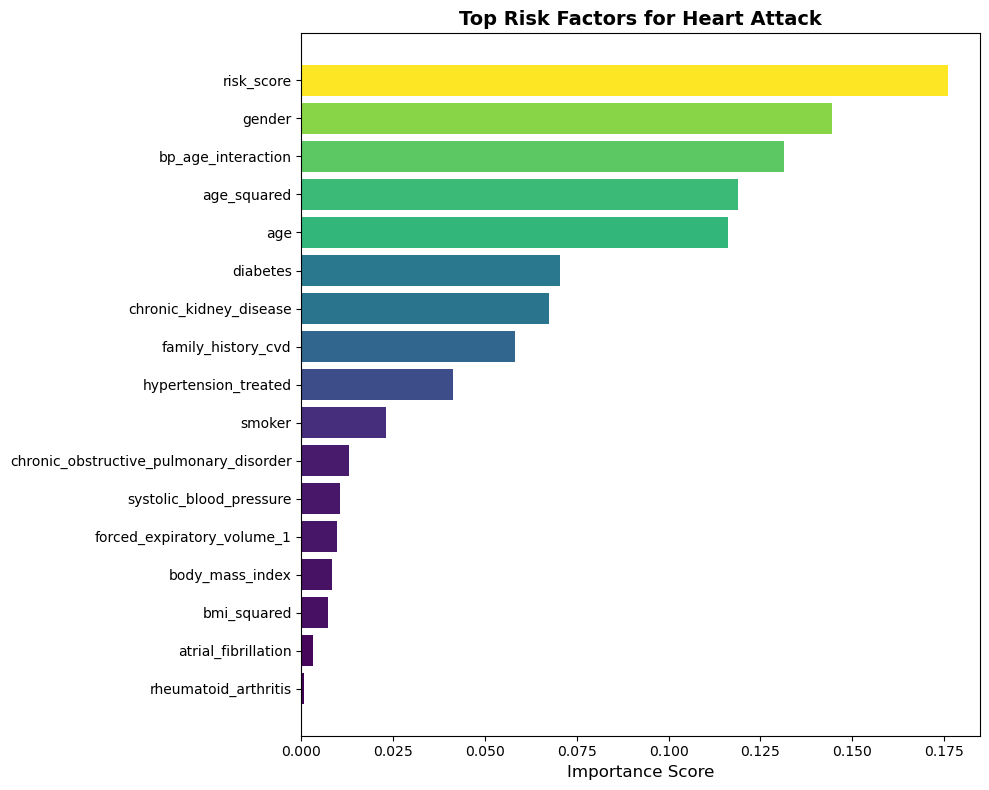


TOP 10 RISK FACTORS
17. risk_score: 0.1760 (17.6%)
1. gender: 0.1444 (14.4%)
16. bp_age_interaction: 0.1314 (13.1%)
14. age_squared: 0.1190 (11.9%)
2. age: 0.1162 (11.6%)
11. diabetes: 0.0705 (7.0%)
9. chronic_kidney_disease: 0.0674 (6.7%)
7. family_history_cvd: 0.0581 (5.8%)
6. hypertension_treated: 0.0412 (4.1%)
4. smoker: 0.0231 (2.3%)


In [14]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(feature_importance['importance'] / feature_importance['importance'].max())
plt.barh(range(len(feature_importance)), feature_importance['importance'], color=colors)

plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top Risk Factors for Heart Attack', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TOP 10 RISK FACTORS")
print("="*60)
for i, row in feature_importance.head(10).iterrows():
    print(f"{i+1}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.1f}%)")

In [15]:
import joblib
import json

# Save model and scaler
joblib.dump(ensemble, 'heart_attack_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\n✅ Model saved as 'heart_attack_model.pkl'")
print("✅ Scaler saved as 'scaler.pkl'")

# Save feature names and threshold
model_info = {
    'features': feature_columns,
    'threshold': best_thresh,
    'accuracy': accuracy
}
with open('model_info.json', 'w') as f:
    json.dump(model_info, f)

print(f"\n" + "="*60)
print(f"✅ FINAL MODEL READY!")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Best threshold: {best_thresh}")
print("="*60)


✅ Model saved as 'heart_attack_model.pkl'
✅ Scaler saved as 'scaler.pkl'

✅ FINAL MODEL READY!
Accuracy: 83.97%
Best threshold: 0.4


In [16]:
import tkinter as tk
from tkinter import messagebox, ttk
from PIL import Image, ImageTk
import cv2
import joblib
import json
import numpy as np
import pandas as pd

# Load the saved model and scaler
try:
    model = joblib.load('heart_attack_model.pkl')
    scaler = joblib.load('scaler.pkl')
    with open('model_info.json', 'r') as f:
        model_info = json.load(f)
    features = model_info['features']
    best_threshold = model_info['threshold']
    model_accuracy = model_info['accuracy']
    print("✅ Model loaded successfully!")
    print(f"📊 Model Accuracy: {model_accuracy*100:.1f}%")
    print(f"🎯 Best Threshold: {best_threshold}")
except:
    print("⚠️ Model not found. Please train the model first.")
    model_accuracy = 0.75
    best_threshold = 0.45

# ============ MAIN GUI WINDOW ============
root = tk.Tk()
root.title("Heart Attack Prediction System")
root.geometry("1000x800")
root.configure(bg='#010621')

def center_window(win, width=400, height=300):
    """Center window on screen"""
    win.update_idletasks()
    screen_width = win.winfo_screenwidth()
    screen_height = win.winfo_screenheight()
    x = (screen_width // 2) - (width // 2)
    y = (screen_height // 2) - (height // 2)
    win.geometry(f"{width}x{height}+{x}+{y}")

center_window(root, 1000, 800)

# ============ VIDEO BACKGROUND ============
try:
    video_path = "Motion_Made_-_Free_Cardiogram_heartbeat_heat_pulse_glowing_red_neon_light_loop_animated_background(1080p).mp4"
    cap = cv2.VideoCapture(video_path)
    if cap.isOpened():
        bg_label = tk.Label(root)
        bg_label.place(relwidth=1, relheight=1)
        
        def play_video():
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, (root.winfo_width(), root.winfo_height()))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img = ImageTk.PhotoImage(Image.fromarray(frame))
                bg_label.config(image=img)
                bg_label.image = img
                root.after(33, play_video)
            else:
                cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                play_video()
        play_video()
    else:
        root.configure(bg='#010621')
except:
    root.configure(bg='#010621')

# ============ GAUGE FUNCTIONS ============
def draw_gauge(canvas, risk_percentage, color):
    """Draw a speedometer-style gauge"""
    canvas.delete("all")
    angle = int((risk_percentage / 100) * 180)
    
    # Background arc
    canvas.create_arc(20, 20, 180, 180, start=0, extent=180, 
                     style="arc", width=13, outline=color)
    # Foreground arc
    canvas.create_arc(20, 20, 180, 180, start=0, extent=180 - angle, 
                     style="arc", width=15, outline="lightgray")
    # Percentage text
    canvas.create_text(100, 120, text=f"{risk_percentage:.1f}%", 
                      font=("Arial", 18, "bold"), fill=color)

def animate_gauge(canvas, risk_percentage, color, step=5):
    """Animate the gauge"""
    for i in range(0, int(risk_percentage) + 1, step):
        draw_gauge(canvas, i, color)
        canvas.update()
        canvas.after(20)

# ============ PREDICTION FUNCTION ============
def predict_heart_attack():
    try:
        # Get all input values
        gender = 1 if gender_var.get() == "Male" else 0
        age = float(entry_age.get())
        bmi = float(entry_bmi.get())
        smoker = 1 if smoker_var.get() == "Yes" else 0
        sbp = float(entry_sbp.get())
        hypertension = 1 if hypertension_var.get() == "Yes" else 0
        family_history = 1 if family_history_var.get() == "Yes" else 0
        atrial_fib = 1 if atrial_fib_var.get() == "Yes" else 0
        kidney_disease = 1 if kidney_var.get() == "Yes" else 0
        rheumatoid = 1 if rheumatoid_var.get() == "Yes" else 0
        diabetes = 1 if diabetes_var.get() == "Yes" else 0
        copd = 1 if copd_var.get() == "Yes" else 0
        fev1 = float(entry_fev1.get())
        
        # Validation
        if age < 18 or age > 120:
            messagebox.showerror("Input Error", "Please enter valid age (18-120)")
            return
        if bmi < 10 or bmi > 60:
            messagebox.showerror("Input Error", "Please enter valid BMI (10-60)")
            return
        if sbp < 50 or sbp > 250:
            messagebox.showerror("Input Error", "Please enter valid systolic BP (50-250)")
            return
        if fev1 < 0.5 or fev1 > 8:
            messagebox.showerror("Input Error", "Please enter valid FEV1 (0.5-8.0)")
            return
        
        # Calculate engineered features
        age_squared = age ** 2
        bmi_squared = bmi ** 2
        bp_age_interaction = sbp * age / 100
        risk_score = (smoker + hypertension + diabetes + family_history + 
                      atrial_fib + kidney_disease + rheumatoid + copd)
        
        # Create input array
        input_data = [[gender, age, bmi, smoker, sbp, hypertension, 
                       family_history, atrial_fib, kidney_disease, 
                       rheumatoid, diabetes, copd, fev1,
                       age_squared, bmi_squared, bp_age_interaction, risk_score]]
        
        # Scale and predict
        input_df = pd.DataFrame(input_data, columns=features)
        input_scaled = scaler.transform(input_df)
        probability = model.predict_proba(input_scaled)[0][1]
        prediction = 1 if probability >= best_threshold else 0
        
        # Convert to percentage
        risk_percentage = probability * 100
        
        # Determine risk level
        if risk_percentage < 20:
            risk_level = "Low Risk"
            color = "green"
            recommendation = "✅ Maintain healthy lifestyle. Regular check-ups recommended."
            icon = "🟢"
        elif risk_percentage < 40:
            risk_level = "Mild Risk"
            color = "lightgreen"
            recommendation = "⚠️ Minor risk factors detected. Consider lifestyle improvements."
            icon = "🟡"
        elif risk_percentage < 60:
            risk_level = "Moderate Risk"
            color = "orange"
            recommendation = "⚠️⚠️ Consult your doctor. Lifestyle changes strongly advised."
            icon = "🟠"
        elif risk_percentage < 80:
            risk_level = "High Risk"
            color = "darkorange"
            recommendation = "🔴🔴 Medical consultation urgently advised."
            icon = "🔴"
        else:
            risk_level = "Very High Risk"
            color = "red"
            recommendation = "🚨🚨 URGENT: Seek immediate medical attention!"
            icon = "💀"
        
        # Create result window
        result_window = tk.Toplevel(root)
        result_window.title("Prediction Result")
        result_window.geometry("650x600")
        result_window.configure(bg="#010621")
        center_window(result_window, 650, 600)
        
        # Main frame
        main_frame = tk.Frame(result_window, bg="#010621")
        main_frame.pack(expand=True, fill='both', padx=20, pady=20)
        
        # Model accuracy badge
        acc_badge = tk.Label(
            main_frame, text=f"🎯 Model Accuracy: {model_accuracy*100:.1f}% | Threshold: {best_threshold}", 
            font=("Arial", 10, "bold"), fg="gold", bg="#010621"
        )
        acc_badge.pack(pady=5)
        
        # Risk level
        result_label = tk.Label(
            main_frame, text=f"{icon} Heart Attack Risk: {risk_level} {icon}", 
            font=("Arial", 20, "bold"), fg=color, bg="#010621"
        )
        result_label.pack(pady=10)
        
        # Probability
        prob_label = tk.Label(
            main_frame, text=f"Risk Probability: {risk_percentage:.1f}%", 
            font=("Arial", 16, "bold"), fg="white", bg="#010621"
        )
        prob_label.pack(pady=5)
        
        # Gauge
        canvas = tk.Canvas(main_frame, width=200, height=150, 
                          bg="#010621", highlightthickness=0)
        canvas.pack(pady=10)
        animate_gauge(canvas, risk_percentage, color)
        
        # Recommendation
        rec_label = tk.Label(
            main_frame, text=f"📋 Recommendation:\n{recommendation}", 
            font=("Arial", 12), fg="lightblue", bg="#010621", 
            wraplength=550, justify="center"
        )
        rec_label.pack(pady=15)
        
        # Risk factors summary
        risk_factors = []
        if age > 50:
            risk_factors.append(f"Age ({age} years)")
        if smoker == 1:
            risk_factors.append("Smoking")
        if sbp > 130:
            risk_factors.append(f"High BP ({sbp} mmHg)")
        if bmi > 25:
            risk_factors.append(f"High BMI ({bmi})")
        if diabetes == 1:
            risk_factors.append("Diabetes")
        if family_history == 1:
            risk_factors.append("Family History")
        if hypertension == 1:
            risk_factors.append("Hypertension")
        
        if risk_factors:
            risk_text = "⚠️ Risk factors present: " + ", ".join(risk_factors)
            risk_label = tk.Label(
                main_frame, text=risk_text, 
                font=("Arial", 10), fg="yellow", bg="#010621", wraplength=550
            )
            risk_label.pack(pady=5)
        else:
            good_label = tk.Label(
                main_frame, text="✅ No major risk factors detected!", 
                font=("Arial", 10), fg="lightgreen", bg="#010621"
            )
            good_label.pack(pady=5)
        
        # Prediction result
        if prediction == 1:
            result_text = "⚠️ PREDICTION: High probability of heart attack. Please consult a doctor immediately!"
            result_color = "red"
        else:
            result_text = "✅ PREDICTION: Low probability of heart attack. Keep maintaining healthy habits!"
            result_color = "lightgreen"
        
        pred_label = tk.Label(
            main_frame, text=result_text, 
            font=("Arial", 11, "bold"), fg=result_color, bg="#010621", wraplength=550
        )
        pred_label.pack(pady=10)
        
        # Disclaimer
        disclaimer = tk.Label(
            main_frame, text="⚠️ Medical Disclaimer: This tool is for educational purposes only.\n"
                       "Always consult a healthcare professional for medical advice.", 
            font=("Arial", 8), fg="gray", bg="#010621", justify="center"
        )
        disclaimer.pack(pady=10)
        
        # Close button
        close_btn = tk.Button(
            main_frame, text="Close", command=result_window.destroy,
            font=("Arial", 10), bg="#A10101", fg="white", padx=20, pady=5,
            cursor="hand2"
        )
        close_btn.pack(pady=10)
        
    except ValueError as e:
        messagebox.showerror("Input Error", f"Please enter valid numeric values.\nError: {str(e)}")
    except Exception as e:
        messagebox.showerror("Error", f"An error occurred: {str(e)}")

# ============ GUI INPUT FORM ============
# Title
title_label = tk.Label(
    root, text="❤️ HEART ATTACK PREDICTION SYSTEM ❤️", 
    font=("Arial", 18, "bold"), bg="#A10101", fg="white", 
    padx=20, pady=10
)
title_label.pack(pady=15)

# Accuracy display
accuracy_label = tk.Label(
    root, text=f"📊 Model Accuracy: {model_accuracy*100:.1f}% | Early Warning System", 
    font=("Arial", 12, "bold"), bg="black", fg="#00FF00"
)
accuracy_label.pack(pady=5)

# Create scrollable frame for inputs
canvas_frame = tk.Canvas(root, height=550, bg="#010621", highlightthickness=0)
scrollbar = tk.Scrollbar(root, orient="vertical", command=canvas_frame.yview)
scrollable_frame = tk.Frame(canvas_frame, bg="#112FDA")

scrollable_frame.bind(
    "<Configure>",
    lambda e: canvas_frame.configure(scrollregion=canvas_frame.bbox("all"))
)

canvas_frame.create_window((0, 0), window=scrollable_frame, anchor="nw")
canvas_frame.configure(yscrollcommand=scrollbar.set)

# Input frame
input_frame = tk.Frame(scrollable_frame, bg="#112FDA", padx=20, pady=20, bd=5, relief="ridge")
input_frame.pack(pady=10, padx=10)

def create_label(parent, text, row, column):
    """Create styled label"""
    tk.Label(parent, text=text, fg="white", bg="#112FDA", 
             padx=7, pady=2, font=("Arial", 11, "bold"))\
        .grid(row=row, column=column, padx=10, pady=8, sticky="w")

def create_radio(parent, text, variable, value, row, column):
    """Create styled radio button"""
    tk.Radiobutton(parent, text=text, font=("Arial", 10), fg="white", bg="#314DED",
                   activebackground="#314DED", activeforeground="black",
                   cursor="hand2", selectcolor="#01158C", relief="flat", 
                   borderwidth=2, indicatoron=0, padx=10, pady=5,
                   variable=variable, value=value)\
        .grid(row=row, column=column, sticky="w", padx=12, pady=5)

def create_entry(parent, row, column):
    """Create styled entry"""
    entry = tk.Entry(parent, font=("Arial", 11), width=20, bg="white", fg="black")
    entry.grid(row=row, column=column, columnspan=2, sticky="we", padx=5, pady=5)
    return entry

# Row counter
row = 0

# Gender
create_label(input_frame, "Gender:", row, 0)
gender_var = tk.StringVar(value="Male")
create_radio(input_frame, "👨 Male", gender_var, "Male", row, 1)
create_radio(input_frame, "👩 Female", gender_var, "Female", row, 2)
row += 1

# Age
create_label(input_frame, "Age (years):", row, 0)
entry_age = create_entry(input_frame, row, 1)
row += 1

# BMI
create_label(input_frame, "Body Mass Index (BMI):", row, 0)
entry_bmi = create_entry(input_frame, row, 1)
row += 1

# Smoker
create_label(input_frame, "Current Smoker:", row, 0)
smoker_var = tk.StringVar(value="No")
create_radio(input_frame, "✅ Yes", smoker_var, "Yes", row, 1)
create_radio(input_frame, "❌ No", smoker_var, "No", row, 2)
row += 1

# Systolic BP
create_label(input_frame, "Systolic Blood Pressure (mmHg):", row, 0)
entry_sbp = create_entry(input_frame, row, 1)
row += 1

# Hypertension Treated
create_label(input_frame, "Hypertension (Treated):", row, 0)
hypertension_var = tk.StringVar(value="No")
create_radio(input_frame, "✅ Yes", hypertension_var, "Yes", row, 1)
create_radio(input_frame, "❌ No", hypertension_var, "No", row, 2)
row += 1

# Family History
create_label(input_frame, "Family History of CVD:", row, 0)
family_history_var = tk.StringVar(value="No")
create_radio(input_frame, "✅ Yes", family_history_var, "Yes", row, 1)
create_radio(input_frame, "❌ No", family_history_var, "No", row, 2)
row += 1

# Atrial Fibrillation
create_label(input_frame, "Atrial Fibrillation:", row, 0)
atrial_fib_var = tk.StringVar(value="No")
create_radio(input_frame, "✅ Yes", atrial_fib_var, "Yes", row, 1)
create_radio(input_frame, "❌ No", atrial_fib_var, "No", row, 2)
row += 1

# Chronic Kidney Disease
create_label(input_frame, "Chronic Kidney Disease:", row, 0)
kidney_var = tk.StringVar(value="No")
create_radio(input_frame, "✅ Yes", kidney_var, "Yes", row, 1)
create_radio(input_frame, "❌ No", kidney_var, "No", row, 2)
row += 1

# Rheumatoid Arthritis
create_label(input_frame, "Rheumatoid Arthritis:", row, 0)
rheumatoid_var = tk.StringVar(value="No")
create_radio(input_frame, "✅ Yes", rheumatoid_var, "Yes", row, 1)
create_radio(input_frame, "❌ No", rheumatoid_var, "No", row, 2)
row += 1

# Diabetes
create_label(input_frame, "Diabetes:", row, 0)
diabetes_var = tk.StringVar(value="No")
create_radio(input_frame, "✅ Yes", diabetes_var, "Yes", row, 1)
create_radio(input_frame, "❌ No", diabetes_var, "No", row, 2)
row += 1

# COPD
create_label(input_frame, "COPD:", row, 0)
copd_var = tk.StringVar(value="No")
create_radio(input_frame, "✅ Yes", copd_var, "Yes", row, 1)
create_radio(input_frame, "❌ No", copd_var, "No", row, 2)
row += 1

# FEV1
create_label(input_frame, "FEV1 (Forced Expiratory Volume):", row, 0)
entry_fev1 = create_entry(input_frame, row, 1)
row += 1

# Pack scrollable frame
canvas_frame.pack(side="left", fill="both", expand=True, padx=10, pady=10)
scrollbar.pack(side="right", fill="y")

# ============ PREDICT BUTTON ============
def on_enter(e):
    btn_predict.config(bg='#E03030')

def on_leave(e):
    btn_predict.config(bg='#A10101')

btn_predict = tk.Button(
    root, text="🔍 PREDICT HEART ATTACK RISK 🔍", 
    command=predict_heart_attack, 
    font=("Arial", 14, "bold"), bg="#A10101", fg="white", 
    padx=30, pady=12, cursor="hand2"
)
btn_predict.pack(pady=15)
btn_predict.bind("<Enter>", on_enter)
btn_predict.bind("<Leave>", on_leave)

# Reset button
def reset_form():
    entry_age.delete(0, tk.END)
    entry_bmi.delete(0, tk.END)
    entry_sbp.delete(0, tk.END)
    entry_fev1.delete(0, tk.END)
    gender_var.set("Male")
    smoker_var.set("No")
    hypertension_var.set("No")
    family_history_var.set("No")
    atrial_fib_var.set("No")
    kidney_var.set("No")
    rheumatoid_var.set("No")
    diabetes_var.set("No")
    copd_var.set("No")

btn_reset = tk.Button(
    root, text="🔄 Reset Form", 
    command=reset_form, 
    font=("Arial", 11), bg="#314DED", fg="white", 
    padx=20, pady=8, cursor="hand2"
)
btn_reset.pack(pady=5)

# Info label
info_label = tk.Label(
    root, text="💡 Enter all patient information for accurate prediction | Early detection saves lives", 
    font=("Arial", 9), bg="black", fg="white"
)
info_label.pack(pady=5)

print("\n" + "="*60)
print("✅ GUI APPLICATION READY")
print("="*60)
print("Enter patient information and click 'Predict'")
print("Close the window to exit")

# Run the GUI
root.mainloop()

# Cleanup
try:
    cap.release()
except:
    pass
cv2.destroyAllWindows()

✅ Model loaded successfully!
📊 Model Accuracy: 84.0%
🎯 Best Threshold: 0.4

✅ GUI APPLICATION READY
Enter patient information and click 'Predict'
Close the window to exit
